In [16]:
# 1. 시스템 패키지 리스트 업데이트
!apt-get update

# 2. Tesseract OCR 엔진과 한국어 언어팩 설치
!apt-get install -y tesseract-ocr tesseract-ocr-kor

# 3. OCR 및 데이터 처리에 필요한 Python 라이브러리 설치
!pip install pytesseract opencv-python-headless pandas

Get:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,801 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,750 kB]
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,063 kB]
Get:13 http://archive.ubuntu.com/ubuntu jamm

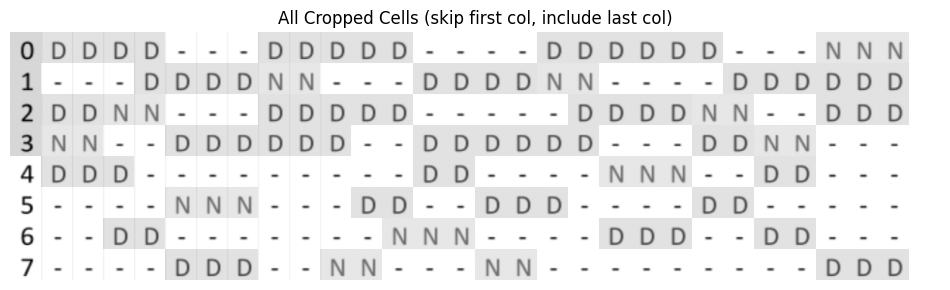

In [47]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ───────────────────────────────────────────
# 0) Load & preprocess
# ───────────────────────────────────────────
img     = cv2.imread("/content/schedule3.png")
gray    = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
bin_inv = cv2.adaptiveThreshold(
    gray, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    15, 8
)

# ───────────────────────────────────────────
# 1) Extract & solidify dotted grid lines
# ───────────────────────────────────────────
h_k    = cv2.getStructuringElement(cv2.MORPH_RECT, (gray.shape[1]//30, 1))
v_k    = cv2.getStructuringElement(cv2.MORPH_RECT, (1, gray.shape[0]//30))
h_l    = cv2.morphologyEx(bin_inv, cv2.MORPH_OPEN,  h_k, iterations=2)
v_l    = cv2.morphologyEx(bin_inv, cv2.MORPH_OPEN,  v_k, iterations=2)
h_s    = cv2.morphologyEx(h_l, cv2.MORPH_CLOSE,
                          cv2.getStructuringElement(cv2.MORPH_RECT,(80,1)))
v_s    = cv2.morphologyEx(v_l, cv2.MORPH_CLOSE,
                          cv2.getStructuringElement(cv2.MORPH_RECT,(1,80)))
inter  = cv2.bitwise_and(h_s, v_s)

# ───────────────────────────────────────────
# 2) Cluster intersections → y_lines, x_lines
# ───────────────────────────────────────────
pts     = np.column_stack(np.where(inter>0))
ys, xs  = np.sort(pts[:,0]), np.sort(pts[:,1])

def cluster(vals, tol=8):
    groups = [[vals[0]]]
    for v in vals[1:]:
        if abs(v - groups[-1][-1]) < tol:
            groups[-1].append(v)
        else:
            groups.append([v])
    return [int(np.mean(g)) for g in groups]

y_lines = cluster(ys, tol=8)
x_lines = cluster(xs, tol=8)

# include image borders
h, w = gray.shape
for arr, LIM in ((y_lines, h), (x_lines, w)):
    if 0   not in arr: arr.insert(0, 0)
    if LIM not in arr: arr.append(LIM)
y_lines.sort()
x_lines.sort()

# ───────────────────────────────────────────
# 3) Now: skip the very first grid‐cell (labels) → x_lines[1:]
#    but we want to include *all* remaining cells up to the last one
# ───────────────────────────────────────────
PAD = 2

# Build two parallel lists of cell‐column boundaries:
#   starts = x_lines[1], ..., x_lines[-2]
#   ends   = x_lines[2], ..., x_lines[-1]
starts = x_lines[1:-1]
ends   = x_lines[2:   ]

NUM_WORKERS = 8
# skip top header row → y_lines[1:1+8] & y_lines[2:2+8]
y_starts = y_lines[1 : 1+NUM_WORKERS]
y_ends   = y_lines[2 : 2+NUM_WORKERS]

# ───────────────────────────────────────────
# 4) Crop & mosaic
# ───────────────────────────────────────────
cells = []
for ys_, ye_ in zip(y_starts, y_ends):
    row = []
    y0, y1 = ys_ + PAD, ye_ - PAD
    for xs_, xe_ in zip(starts, ends):
        x0, x1 = xs_ + PAD, xe_ - PAD
        row.append(gray[y0:y1, x0:x1])
    cells.append(row)

# Show mosaic
thumb_h, thumb_w = 32, 32
mosaic = np.zeros((thumb_h*NUM_WORKERS, thumb_w*len(starts)), dtype=np.uint8)
for i in range(NUM_WORKERS):
    for j in range(len(starts)):
        mosaic[i*thumb_h:(i+1)*thumb_h, j*thumb_w:(j+1)*thumb_w] = \
            cv2.resize(cells[i][j], (thumb_w, thumb_h))

plt.figure(figsize=(12,6))
plt.imshow(mosaic, cmap='gray')
plt.axis('off')
plt.title("All Cropped Cells (skip first col, include last col)")
plt.show()


In [39]:
import cv2
import numpy as np
import pytesseract
import json
import re

# ─────────────────────────────────────────────────────────
# 1) Load & preprocess
# ─────────────────────────────────────────────────────────
img    = cv2.imread("schedule3.png")
gray   = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
bin_inv= cv2.adaptiveThreshold(
    gray,255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    15,8
)

# ─────────────────────────────────────────────────────────
# 2) Extract dotted grid lines → close gaps → intersections
# ─────────────────────────────────────────────────────────
h_k    = cv2.getStructuringElement(cv2.MORPH_RECT,(gray.shape[1]//30,1))
v_k    = cv2.getStructuringElement(cv2.MORPH_RECT,(1,gray.shape[0]//30))
h_l    = cv2.morphologyEx(bin_inv, cv2.MORPH_OPEN,  h_k, iterations=2)
v_l    = cv2.morphologyEx(bin_inv, cv2.MORPH_OPEN,  v_k, iterations=2)
h_s    = cv2.morphologyEx(h_l, cv2.MORPH_CLOSE,
                          cv2.getStructuringElement(cv2.MORPH_RECT,(80,1)))
v_s    = cv2.morphologyEx(v_l, cv2.MORPH_CLOSE,
                          cv2.getStructuringElement(cv2.MORPH_RECT,(1,80)))
inter  = cv2.bitwise_and(h_s, v_s)

# ─────────────────────────────────────────────────────────
# 3) Cluster intersection points into grid lines
# ─────────────────────────────────────────────────────────
pts = np.column_stack(np.where(inter>0))  # (y,x) pairs
ys, xs = np.sort(pts[:,0]), np.sort(pts[:,1])

def cluster(vals, tol=8):
    groups = [[vals[0]]]
    for v in vals[1:]:
        if abs(v-groups[-1][-1])<tol:
            groups[-1].append(v)
        else:
            groups.append([v])
    return [int(np.mean(g)) for g in groups]

y_lines = cluster(ys, tol=8)
x_lines = cluster(xs, tol=8)

# include image borders
h,w = gray.shape
for arr, lim in ((y_lines,h),(x_lines,w)):
    if 0 not in arr: arr.insert(0,0)
    if lim not in arr: arr.append(lim)
y_lines.sort(); x_lines.sort()

# ─────────────────────────────────────────────────────────
# 4) Crop each cell
# ─────────────────────────────────────────────────────────
NUM_WORKERS = 8   # rows 1–8 after skipping header
NUM_DAYS    = 28  # cols 1–28 after skipping label
pad = 2

cells = []
for i in range(1, 1+NUM_WORKERS):
    y0,y1 = y_lines[i]+pad, y_lines[i+1]-pad
    row = []
    for j in range(1, 1+NUM_DAYS):
        x0,x1 = x_lines[j]+pad, x_lines[j+1]-pad
        row.append(gray[y0:y1, x0:x1])
    cells.append(row)

# ─────────────────────────────────────────────────────────
# 5) OCR each cell → build JSON
# ─────────────────────────────────────────────────────────
# single character, whitelist D,N and dash
tess_cfg = '--psm 10 -c tessedit_char_whitelist=DN-'
result = {}

for i in range(NUM_WORKERS):
    result[str(i)] = {}
    for j in range(NUM_DAYS):
        cell_img = cells[i][j]
        txt = pytesseract.image_to_string(cell_img, config=tess_cfg).strip()
        # keep only D, N, or '-'
        m = re.search(r'[DN-]', txt)
        result[str(i)][str(j)] = m.group(0) if m else '-'

# ─────────────────────────────────────────────────────────
# 6) Output JSON
# ─────────────────────────────────────────────────────────
print(json.dumps(result, ensure_ascii=False, indent=2))


{
  "0": {
    "0": "-",
    "1": "D",
    "2": "D",
    "3": "D",
    "4": "D",
    "5": "-",
    "6": "-",
    "7": "-",
    "8": "D",
    "9": "D",
    "10": "D",
    "11": "D",
    "12": "D",
    "13": "-",
    "14": "-",
    "15": "-",
    "16": "-",
    "17": "D",
    "18": "D",
    "19": "D",
    "20": "D",
    "21": "D",
    "22": "D",
    "23": "-",
    "24": "-",
    "25": "-",
    "26": "N",
    "27": "N"
  },
  "1": {
    "0": "-",
    "1": "-",
    "2": "-",
    "3": "-",
    "4": "D",
    "5": "D",
    "6": "D",
    "7": "D",
    "8": "N",
    "9": "N",
    "10": "-",
    "11": "-",
    "12": "-",
    "13": "D",
    "14": "D",
    "15": "D",
    "16": "D",
    "17": "N",
    "18": "N",
    "19": "-",
    "20": "-",
    "21": "-",
    "22": "-",
    "23": "D",
    "24": "D",
    "25": "D",
    "26": "D",
    "27": "D"
  },
  "2": {
    "0": "-",
    "1": "D",
    "2": "D",
    "3": "N",
    "4": "N",
    "5": "-",
    "6": "-",
    "7": "-",
    "8": "D",
    "9": "D",
   